<a href="https://colab.research.google.com/github/rgrandym/data_science_cambridge/blob/main/CAM_DS_C101_Mini_project_5_3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**First things first** - please go to 'File' and select 'Save a copy in Drive' so that you have your own version of this activity set up and ready to use.
Remember to update your Course 1 notebook with links to your own work once completed!

# Mini-project 5.3 Detecting the anomalous activity of a ship’s engine

## **Business context**
You are provided with a real data set to identify anomalous activity in a ship’s engine functionality (Devabrat,  2022). As you work through this project, keep in mind that, typically speaking, anomalies would make up a minority of the data points (i.e., about 1% to 5% of the data points would be anomalies).

The data set contains six important features continuously monitored to evaluate the engine's status as ‘good’ or ‘bad’. These features are:
- **Engine rpm (revolutions per minute):** A high rpm indicates the engine is operating at a higher speed than designed for prolonged periods, which can lead to overheating, excessive wear, and eventual failure. A low rpm could signal a lack of power, issues with fuel delivery, or internal mechanical problems.
- **Lubrication oil pressure:** Low lubrication oil pressure indicates insufficient lubrication, leading to increased friction, overheating, and engine damage. A high lubrication oil pressure could signal a blockage in the oil delivery system, potentially causing seal or gasket failure.
- **Fuel pressure:** High fuel pressure can cause poor engine performance and incomplete combustion, indicating fuel pump or filter issues. A low fuel pressure may result in excessive fuel consumption, poor emissions, or damage to the fuel injectors.
- **Coolant pressure:** Low coolant pressure indicates a potential leak in the cooling system or a coolant pump failure, risking engine overheating. A high coolant pressure could be a sign of a blockage in the cooling system or a failing head gasket, which can also lead to overheating.
- **Lubrication oil temperature:** High lubrication oil temperature suggests the oil is overheating, which can degrade its lubricating properties and lead to engine damage. A low lubrication oil temperature may indicate it is not reaching its optimal operating temperature, potentially causing inadequate lubrication.
- **Coolant temperature:** High coolant temperature signals overheating, which various issues, including a failed thermostat, coolant leak, or insufficient coolant flow can cause. A low coolant temperature could suggest the engine is not reaching its optimal operating temperature, affecting performance and efficiency.

Issues with engines could lead to engine malfunctions, potential safety hazards, and downtime (e.g. delayed deliveries), resulting in the breakdown of a ship’s overall functionality, consequently impacting the business, such as affecting revenue via failure to deliver goods. By predicting timely maintenance, the business aims to increase profit by reducing downtime, reducing safety risks for the crew, limiting fuel consumption, and increasing customer satisfaction through timely deliveries.

Your task is to develop a robust anomaly detection system to protect a company’s shipping fleet by evaluating engine functionality. Therefore, you’ll explore the data and:
- employ preprocessing and feature engineering
- perform model training, anomaly detection, post-processing, and refinement.

You must prepare a report illustrating your insights to the prospective stakeholders, showing how your solution will save the business money and build trust with its stakeholders. At this stage of the project, the main question you need to consider is:
- What insights can be gained from the data, and what recommendations can be made to the company based on these insights? For example, which features need to be monitored closely, and what are the thresholds for anomalous observations? Which statistical or ML technique is the best for anomaly detection based on **this data set**, and which feature (univariate approach) or combination of features (multivariate approach) can predict maintenance?

<br></br>


## **Objective**
By the end of this mini-project, you will be able to understand and apply statistical and ML methods for detecting anomalies.

In the Notebook, you will:
- explore the data set
- preprocess the data and conduct feature engineering
- apply statistical techniques to detect anomalies
- use ML algorithms to detect anomalies.

You will also write a report summarising the results of your findings and recommendations.



<br></br>
> **Declaration**
>
> By submitting your project, you indicate that the work is your own and has been created with academic integrity. Refer to the Cambridge plagiarism regulations.

> Start your activity here. Select the pen from the toolbar to add your entry.

## Mini Project 5.3

Author: Rodrigo Grandy, PhD
Date: 18-02-2025

#### Import required libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import StandardScaler
from scipy.stats import kstest
from scipy.stats import pearsonr, spearmanr
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from matplotlib_venn import venn3
from sklearn.metrics import confusion_matrix


#### Import Data

In [1]:
# URL to import data set from GitHub.
url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'
# Convert cvs file into pandas dataframe
df = pd.read_csv(url)

NameError: name 'pd' is not defined

In [ ]:
# Quick visualization of the data and data file structure
print(df.info())
print(df.shape)
df.head(2)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 915.8 KB
None
(19535, 6)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314


#### Exploratory Data Analysis (EDA)

In [ ]:
# Calculate quick summary statistics
df.describe().round(2)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
count,19535.00,19535.00,19535.00,19535.00,19535.00,19535.00
mean,791.24,3.30,6.66,2.34,77.64,78.43
std,267.61,1.02,2.76,1.04,3.11,6.21
min,61.00,0.00,0.00,0.00,71.32,61.67
25%,593.00,2.52,4.92,1.60,75.73,73.90
50%,746.00,3.16,6.20,2.17,76.82,78.35
75%,934.00,4.06,7.74,2.85,78.07,82.92
max,2239.00,7.27,21.14,7.48,89.58,195.53


In [ ]:
# Create dataframe with mean and median for each feature
mean_median_df = df.describe().loc[['mean','50%'], :]
# Rename 50% percentile as median
mean_median_df = mean_median_df.rename(index={'mean': 'Mean', '50%': 'Median'})
mean_median_df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
Mean,791.239263,3.303775,6.655615,2.335369,77.64342,78.427433
Median,746.000000,3.162035,6.201720,2.166883,76.81735,78.346662


**Comment:**
The median for all features is slightly to the left of the mean, indicating slight skewness of the data to the right, which suggests that the majority of data points are clustered to the left, with fewer data points that extend far to the right pulling the mean in that direction.

In [ ]:
# Calculate the 95th percentile for each feature with only two decimal numbers
percentile_95 = df.quantile(0.95).round(2)

# Filter rows where at least two features exceed their 95th percentile
# Create a boolean mask for values exceeding the 95th percentile
exceeds_95 = df > percentile_95

# Filter rows where at least two features exceed the 95th percentile
filtered_df = df[exceeds_95.sum(axis=1) >= 2].round(4)

# Calculate the range (min and max) for the filtered values of each feature
range_beyond_95 = filtered_df.agg(['min', 'max'])

print("95th Percentile for Each Feature:")
print(percentile_95)
print(f'\nNumber of rows with at least two features above 95th Percentile: {filtered_df.shape[0]}')
print("\nRange of Values Beyond the 95th Percentile for Each Feature:")
range_beyond_95

95th Percentile for Each Feature:
Engine rpm          1324.00
Lub oil pressure       5.06
Fuel pressure         12.21
Coolant pressure       4.44
lub oil temp          84.94
Coolant temp          88.61
Name: 0.95, dtype: float64

Number of rows with at least two features above 95th Percentile: 678

Range of Values Beyond the 95th Percentile for Each Feature:


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
min,339,0.2141,0.3532,0.0878,72.3406,63.2879
max,2239,6.6152,19.5589,7.0976,89.2863,95.1492


**Comments:**
- The range of values for features in the 95th percentile provides insight into the spread of data in extreme regions. However, in this case, the range of values for features where at least two features exceed their 95th percentile is not particularly informative. This is because the 95th percentile threshold may only be crossed by some features in a given row, while other features may remain below the threshold. As a result, the range for these values can become artificially wide, including values that do not exceed the 95th percentile for all features. If this logic is extended to all possible combinations of features, it is highly likely that the range for each feature will be very broad, encompassing values that do not consistently exceed the 95th percentile threshold across all features.

- Nonetheless, this analysis helps identify rows where multiple features simultaneously exhibit extreme values. This is useful for understanding multivariate outliers and uncovering relationships between features in extreme conditions. Future analyses could focus on specific pairs or groups of features that are known to be related, rather than considering "at least two features" in a general sense.

- Alternatively, it might be valuable to compute summary statistics for the extreme values to better understand their distribution. This could include measures such as the mean, median, standard deviation, or interquartile range (IQR) for values exceeding the 95th percentile. Such an analysis would provide deeper insights into the behavior of extreme values and their implications.


In [ ]:
# Function to highlight values that exceed the 95th percentile
def highlight_exceeds_95(val, percentile_95):
    """
    Highlight values that exceed the 95th percentile in a DataFrame.
    Number of rows displayed can be changed by adjusting the argument passed to head().
    """
    color = 'gray' if val > percentile_95 else ''
    return f'background-color: {color}'

# Subset dataframe for visualization
head_filtered_df = filtered_df.head(20)
# Apply the highlighting to the head_filtered_df DataFrame
styled_df = head_filtered_df.style.apply(lambda x: x.apply(highlight_exceeds_95, percentile_95=percentile_95[x.name]))

# Display the styled DataFrame
print("\nRows Where At Least Two Features Exceed the 95th Percentile (Highlighted):")
display(styled_df)


Rows Where At Least Two Features Exceed the 95th Percentile (Highlighted):


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
1,605,5.466900,6.424400,5.727500,73.222700,74.907300
7,576,5.496000,13.114700,1.251100,78.091400,71.934700
17,1312,5.963400,7.563600,5.932000,77.738900,88.662000
113,1495,3.276200,3.714400,2.495300,85.053200,75.743000
131,830,3.231900,13.479200,2.568100,87.480400,73.428200
144,1762,1.697500,4.327800,2.523400,86.750300,82.393200
157,534,5.922000,18.044700,5.946400,77.292800,74.734400
160,1546,3.903500,6.205300,5.554900,78.825600,73.677700
192,1084,5.172600,6.102300,2.692700,86.370800,79.642800
204,812,5.295500,6.649100,5.859900,76.903300,79.777700


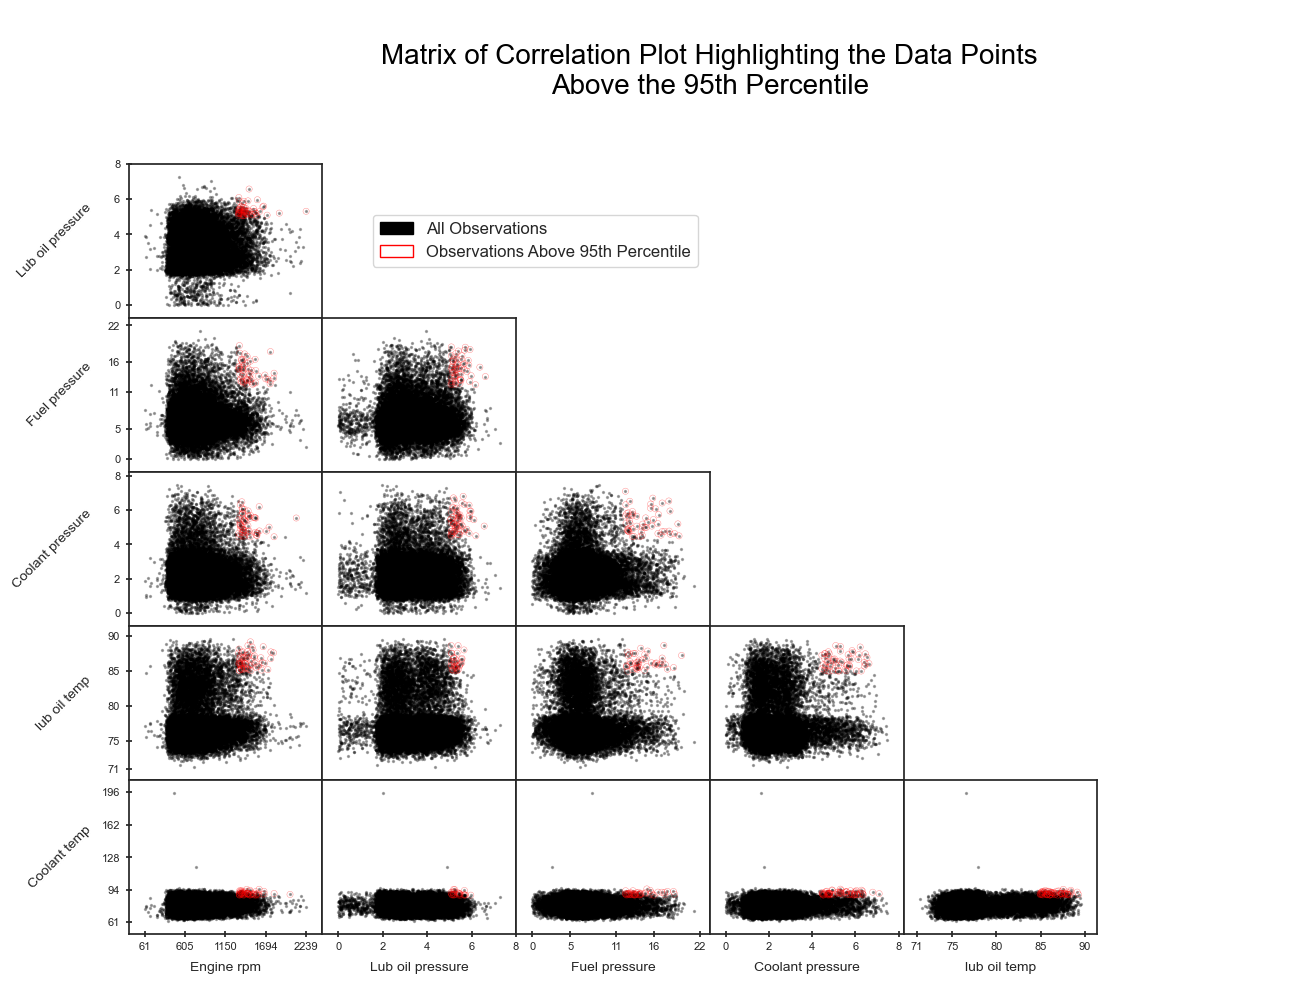

In [ ]:
# Create Matrix of Scatter plots Highlighting data point that are larger than 95th percentile
from matplotlib.patches import Patch 
def plot_correlation_matrices_with_markers(df):
    """
    Plots a scatter plot matrix with points exceeding the 95th percentile highlighted.

    Args:
        df (pd.DataFrame): The input DataFrame containing numerical data.
    """
    # Ensure data is a DataFrame
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input data must be a pandas DataFrame.")

    # Ensure data is numerical
    if not all(pd.api.types.is_numeric_dtype(df[col]) for col in df.columns):
        raise ValueError("All columns in the DataFrame must be numeric.")

    # Calculate the 95th percentile for each feature
    percentile_95 = df.quantile(0.95)

    # Create the figure with custom GridSpec
    fig = plt.figure(figsize=(15, 12))
    gs = gridspec.GridSpec(1, 1)
    ax_scatter = plt.subplot(gs[0, :])  # Single axis for the scatter plot matrix

    # Scatter Plot Matrix
    sns.set(style="ticks")
    num_cols = len(df.columns)
    scatter_axes = [[None for _ in range(num_cols)] for _ in range(num_cols)]

    for i in range(num_cols):
        for j in range(num_cols):
            if j < i:  # Lower triangle: scatter plots
                scatter_axes[i][j] = ax_scatter.inset_axes([j / num_cols, 1 - (i + 1) / num_cols, 1 / num_cols, 1 / num_cols])
                scatter_axes[i][j].scatter(df.iloc[:, j], df.iloc[:, i], s=2, alpha=0.3, color='black')

                # Highlight points exceeding the 95th percentile
                x_col = df.columns[j]
                y_col = df.columns[i]
                x = df[x_col]
                y = df[y_col]
                exceeds_both = (x > percentile_95[x_col]) & (y > percentile_95[y_col])
                scatter_axes[i][j].scatter(x[exceeds_both], y[exceeds_both], 
                                          facecolors='none', edgecolors='red', s=20, linewidths=0.3, alpha=0.5)

                # Set the limits to see the data, add margins
                x_margin = (df.iloc[:, j].max() - df.iloc[:, j].min()) * 0.1
                y_margin = (df.iloc[:, i].max() - df.iloc[:, i].min()) * 0.1
                scatter_axes[i][j].set_xlim(df.iloc[:, j].min() - x_margin, df.iloc[:, j].max() + x_margin)
                scatter_axes[i][j].set_ylim(df.iloc[:, i].min() - y_margin, df.iloc[:, i].max() + y_margin)

                # Remove ticks and labels from internal plots
                scatter_axes[i][j].set_xticks([])
                scatter_axes[i][j].set_yticks([])

                # Set ticks only for the leftmost plots (y-axis)
                if j == 0:
                    scatter_axes[i][j].yaxis.set_ticks_position('left')
                    scatter_axes[i][j].tick_params(axis='y', which='major', labelsize=8, length=5, direction='inout')
                    y_ticks = np.linspace(int(np.floor(df.iloc[:, i].min())), int(np.ceil(df.iloc[:, i].max())), 5).astype(int)
                    scatter_axes[i][j].set_yticks(y_ticks)
                    scatter_axes[i][j].set_yticklabels([f"{tick}" for tick in y_ticks])

                # Set ticks only for the bottom plots (x-axis)
                if i == num_cols - 1:
                    scatter_axes[i][j].xaxis.set_ticks_position('bottom')
                    scatter_axes[i][j].tick_params(axis='x', which='major', labelsize=8, length=5, direction='inout')
                    x_ticks = np.linspace(int(np.floor(df.iloc[:, j].min())), int(np.ceil(df.iloc[:, j].max())), 5).astype(int)
                    scatter_axes[i][j].set_xticks(x_ticks)
                    scatter_axes[i][j].set_xticklabels([f"{tick}" for tick in x_ticks])

    # Adjust position of labels and font size
    label_offset_x = -0.03
    label_offset_y = -0.03

    # Add shared x-axis labels at the bottom (only for scatter plots)
    for j, label in enumerate(df.columns):
        if j < num_cols - 1:  # Skip the last column
            ax_scatter.text(
                (j + 0.5) / num_cols, label_offset_y, label,
                ha='center', va='top', transform=ax_scatter.transAxes,
                rotation=0, fontsize=10)

    # Add shared y-axis labels at the left (only for scatter plots)
    for i, label in enumerate(df.columns):
        if i > 0:  # Skip the first row
            ax_scatter.text(
                label_offset_x, (num_cols - i - 0.5) / num_cols, label,
                ha='right', va='center', transform=ax_scatter.transAxes,
                rotation=45, fontsize=10)

    # Disable ticks and labels for the parent axis
    ax_scatter.set_xticks([])
    ax_scatter.set_yticks([])

    # Remove the external border (spines) of the parent axis
    for spine in ax_scatter.spines.values():
        spine.set_visible(False)

    # Set title for the scatter plot matrix
    ax_scatter.set_title("Matrix of Correlation Plot Highlighting the Data Points\nAbove the 95th Percentile", fontsize=20, y=0.9)
    
    # Add a custom legend on the half-empty part of the matrix
    legend_elements = [
        Patch(facecolor='black', edgecolor='black', label='All Observations'),
        Patch(facecolor='none', edgecolor='red', label='Observations Above 95th Percentile')
    ]
    ax_scatter.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.35, 0.75), fontsize=12)
    # Adjust layout and display
    plt.show()

plot_correlation_matrices_with_markers(df)

In [ ]:
# @tittle Explore Structure of dataframe
# Returns rows with invalid data types within each column of the DataFrame, if present

def identify_main_dtype(column):
    """
    Identify the main data type of a pandas Series.
    """
    if pd.api.types.is_numeric_dtype(column):
        return 'numeric'
    elif pd.api.types.is_datetime64_any_dtype(column):
        return 'datetime'
    elif pd.api.types.is_string_dtype(column):
        return 'string'
    else:
        return 'other'

def check_invalid_values(df):
    """
    Check for invalid values in each column based on the main data type.

    Parameters:
        df (pd.DataFrame): The DataFrame to check.

    Returns:
        pd.DataFrame: A summary DataFrame with only columns that have invalid values.
    """
    results = []

    for column_name in df.columns:
        column = df[column_name]
        main_dtype = identify_main_dtype(column)

        if main_dtype == 'numeric':
            # Check for non-numeric values
            invalid_mask = pd.to_numeric(column, errors='coerce').isna()
        elif main_dtype == 'datetime':
            # Check for invalid datetime values
            invalid_mask = pd.to_datetime(column, errors='coerce').isna()
        elif main_dtype == 'string':
            # Check for non-string values
            invalid_mask = ~column.apply(lambda x: isinstance(x, str))
        else:
            # For other types, assume no invalid values
            invalid_mask = pd.Series(False, index=column.index)

        # Count invalid values
        num_invalid = invalid_mask.sum()
        
        # Determine invalid rows
        invalid_rows = df[invalid_mask].index.tolist() if num_invalid > 0 else None

        # Append results
        results.append({
            'Column': column_name,
            'Main Data Type': main_dtype,
            'Invalid Values Count': num_invalid,
            'Invalid Rows': invalid_rows  # Include row indices
        })

    # Create summary DataFrame
    summary_df = pd.DataFrame(results)

    # Filter summary DataFrame to include only columns with invalid values
    filtered_summary_df = summary_df[summary_df['Invalid Values Count'] > 0]
    
    if filtered_summary_df.empty:
        print(f'All good!. No invalid values in the DataFrame')
        return None
    else: 
        return filtered_summary_df

# Call the functions

identify_main_dtype(df)
check_invalid_values(df)

All good!. No invalid values in the DataFrame


In [ ]:
# @ Create Feature Summary
def create_feature_summary(df):
    """
    Creates a DataFrame where each row represents a feature (column) from the original DataFrame.
    Each row contains the feature name, count of unique values, and the unique values themselves.
    
    Parameters:
        df (pandas.DataFrame): Input DataFrame
        
    Returns:
        pandas.DataFrame: DataFrame with features as rows and unique values as columns
    """
    # Create a list to store the data for each feature
    feature_data = []
    duplicates_data = []
    
    # Process each column in the original DataFrame
    for column in df.columns:
        # Get unique values for this column
        unique_values = df[column].unique()
        
        # Create a row with feature name, count, and the unique values
        row_data = {
            'Feature': column,
            'Unique_Count': len(unique_values)
        }
        
        # # Add each unique value as a separate column
        # for i, val in enumerate(unique_values):
        #     row_data[f'Value_{i+1}'] = val
        
        feature_data.append(row_data)
        
        # # Calculate duplicate values and their counts
        # values_counts = df[column].value_counts()
        # duplicates = values_counts[values_counts > 1]
        # if not duplicates.empty:
        #     for value, count in duplicates.items():
        #         duplicates_data.append({
        #             'Feature': column,
        #             'Duplicates': value,
        #             'Count': count
        #         })
            
    # Create the DataFrame from the collected data
    feature_summary_df = pd.DataFrame(feature_data)
    
    # Create duplicates dataframe
    duplicates_df = pd.DataFrame(duplicates_data)
    
    return feature_summary_df, duplicates_df

# Display the DataFrame
feature_summary_df, duplicates_df = create_feature_summary(df)
feature_summary_df.head(6)

,Feature,Unique_Count
0,Engine rpm,1379
1,Lub oil pressure,19534
2,Fuel pressure,19531
3,Coolant pressure,19534
4,lub oil temp,19530
5,Coolant temp,19532


In [ ]:
# @tittle Calculate duplicates within dataframe
# Create a summary of duplicates in each column
duplicate_stats = {}

for column in df.columns:
    # Count values that appear more than once
    value_counts = df[column].value_counts()
    duplicates = value_counts[value_counts > 1]
    unique_values = df[column].unique()
    
    duplicate_stats[column] = {
        'Total Values': len(df),
        'Unique Values': len(unique_values),
        'Total Duplicate Values': duplicates.sum(),
        'Unique Duplicate Values': len(duplicates),
        'Duplicate Percentage': (duplicates.sum() / len(df)) * 100,    
    }

duplicate_summary = pd.DataFrame(duplicate_stats).T.sort_values('Total Duplicate Values', ascending=False)
duplicate_summary

,Total Values,Unique Values,Total Duplicate Values,Unique Duplicate Values,Duplicate Percentage
Engine rpm,19535.0,1379.0,19362.0,1206.0,99.114410
lub oil temp,19535.0,19530.0,10.0,5.0,0.051190
Fuel pressure,19535.0,19531.0,8.0,4.0,0.040952
Coolant temp,19535.0,19532.0,6.0,3.0,0.030714
Lub oil pressure,19535.0,19534.0,2.0,1.0,0.010238
Coolant pressure,19535.0,19534.0,2.0,1.0,0.010238


**Interpretation Duplicates table**
- Unique Values: Number of distinct values that appear one or more times
- Total Duplicate Values: The number of values that are duplicates of some other value in the column. 
- Unique Duplicate Values: The number of distinct values that appear multiple times. 
- Duplicate Percentage: Percentage of duplicates in the total data.

    - Engine rpm contains 19362 values that appear somewhere else in the column. Only 1206 of these values are causing the duplicates.
    - lub oil temp contains 10 values that appear somewhere else in the column. Only 5 of these values are causing the duplicates.
    - Fuel pressure contains 8 values that appear somewhere else in the column. Only 4 of these values are causing the duplicates.
    - Coolant temp contains 6 values that appear somewhere else in the column. Only 3 of these values are causing the duplicates.
    - Lub oil pressure contains 2 values that appear somewhere else in the column. Only 1 of these values are causing the duplicates.
    - Coolant pressure contains 2 values that appear somewhere else in the column. Only 1 of these values are causing the duplicates.

The high number of duplicates in the Engine rpm category is not inherently problematic, as these values represent the range of rpms at which the engine operates. The other five categories display few duplicate values, which may be of greater interest due to their rarity. Per se, these duplicates are not concerning. Further analysis will be conducted to validate this assumption.


#### Visualization EDA

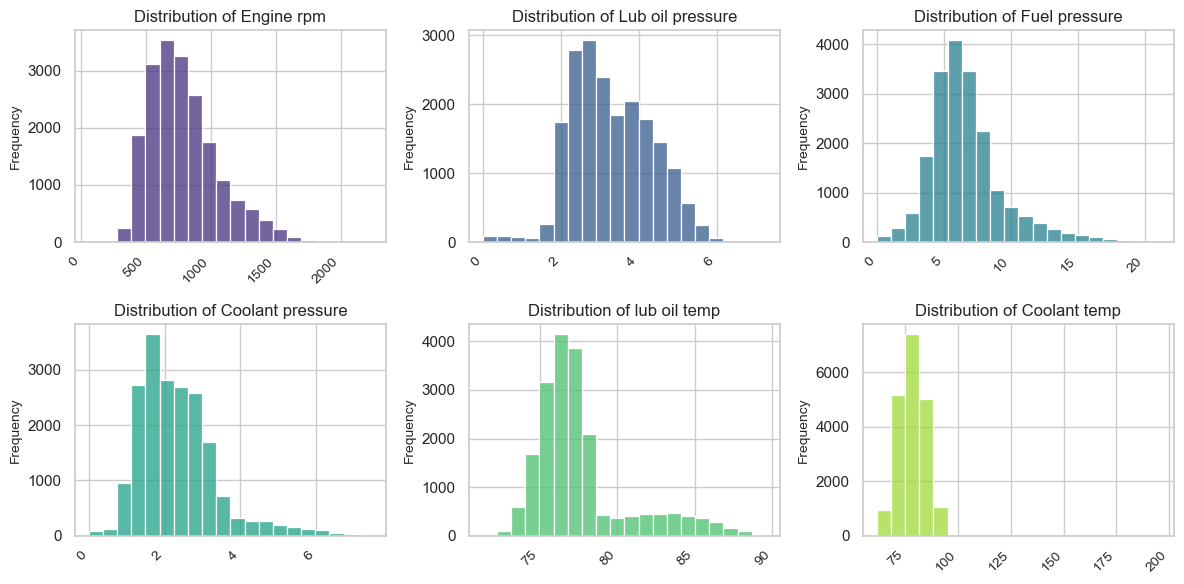

In [ ]:
# @tittle Histograms to Explore Distribution of Data
# Create the histogram
def plot_column_histograms(df, figsize=(20, 12), bins=20, kde=True):
    """
    Create histograms for each column in a DataFrame.
    
    Parameters:
        df (pandas.DataFrame): Input DataFrame
        figsize (tuple): Figure size as (width, height)
        bins (int): Number of bins for histograms
        kde (bool): Whether to include Kernel Density Estimate
    """
    # Set the theme to use Viridis
    sns.set_theme(style="whitegrid", palette="viridis")
    
    # Calculate number of rows and columns for subplots
    n_columns = len(df.columns)
    n_cols = min(3, n_columns)  # Max 3 plots per row
    n_rows = math.ceil(n_columns / n_cols)
    
    # Create subplots for histograms
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Flatten axes array for easier indexing
    if n_rows * n_cols > 1:
        axes = axes.flatten()
    else:
        axes = [axes]  # Make it iterable for a single plot
    
    # Get the Viridis color palette
    viridis_palette = sns.color_palette("viridis", n_colors=n_columns)
    
    # Plot histograms for each column
    for i, column_name in enumerate(df.columns):
        # Plot histogram
        sns.histplot(
            df,
            x=column_name,
            kde=kde,  # Add Kernel Density Estimate
            color=viridis_palette[i],  # Use Viridis color
            bins=bins,  # Number of bins
            ax=axes[i]  # Plot on the corresponding subplot
        )
        
        # Add titles and labels
        axes[i].set_title(f'Distribution of {column_name}', fontsize=12)
        axes[i].set_xlabel(None, fontsize=8, rotation=30)
        axes[i].set_ylabel("Frequency", fontsize=10)
        
        # Adjust axes tick labels 
        # Rotate x-axis labels and adjust font size
        axes[i].tick_params(axis='x', labelrotation=45, labelsize=10)
        # If you need horizontal alignment:
        for label in axes[i].get_xticklabels():
            label.set_ha('right')
    
    # Adjust layout
    plt.tight_layout()

plot_column_histograms(df, figsize=(12, 6), bins=20, kde=False)

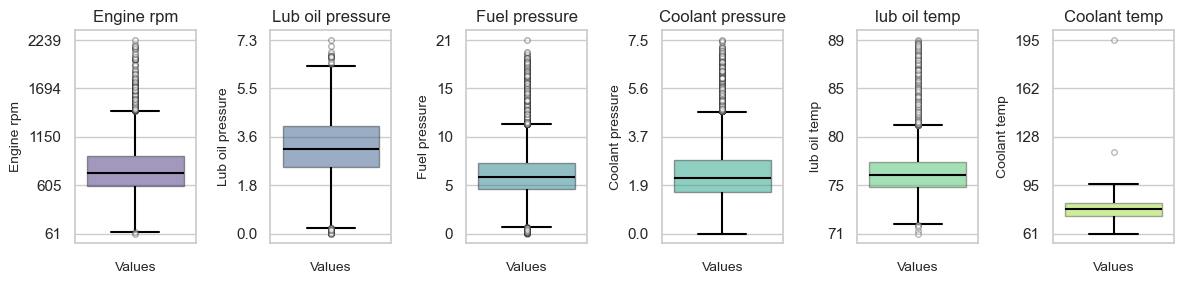

In [ ]:
# @ Box plots

# Create the box plot 

def plot_column_boxplot_melted(df, units=None, figsize=(20, 8)):
    """
    Create horizontal box plots for each column in a DataFrame using
    a melted dataframe approach to handle all column types consistently.
    
    Parameters:
        filtered_df (pandas.DataFrame): Input DataFrame
        units (dict): Dictionary mapping column names to their units (e.g., {'speed': 'km/h'})
        figsize (tuple): Figure size as (width, height)
    """
    # Set default units dictionary if not provided
    if units is None:
        units = {}
    
    # Set the theme to use Viridis
    sns.set_theme(style="whitegrid", palette="viridis")
    
    # Calculate number of rows and columns for subplots
    n_columns = len(df.columns)
    n_cols = min(6, n_columns)  # Max 5 plots per row
    n_rows = math.ceil(n_columns / n_cols)
    
    # Create subplots for box plots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Flatten axes array for easier indexing
    if n_rows * n_cols > 1:
        axes = axes.flatten()
    else:
        axes = [axes]  # Make it iterable for a single plot
    
    # Get the Viridis color palette
    viridis_palette = sns.color_palette("viridis", n_colors=n_columns)
    
    # Process each column separately to create appropriate visualizations
    for i, column_name in enumerate(df.columns):
        # Get data for this column
        data = df[column_name]
        
        # Get unit for this column if available
        unit = units.get(column_name, "")
        unit_suffix = f" ({unit})" if unit else ""
        
        # Check if column is categorical or numeric
        if pd.api.types.is_numeric_dtype(data):
            # Numeric column - create boxplot
            sns.boxplot(
                y=data,
                ax=axes[i],
                color=viridis_palette[i],
                patch_artist=True,
                showfliers=True,
                medianprops={'color': 'black', 'linewidth': 1.5},
                boxprops={'facecolor': viridis_palette[i], 'alpha': 0.5},
                whiskerprops={'linewidth': 1.5, 'color': 'black'},
                capprops={'linewidth': 1.5, 'color': 'black'},
                flierprops={'marker': 'o', 'markerfacecolor': 'white', 'markersize': 4, 'alpha': 0.4}
            )
            
            # Add tick labels for numeric data
            # Get the min, max, and some points in between
            data_min = data.min()
            data_max = data.max()
            data_range = data_max - data_min
            
            # Create tick positions
            if data_range > 0:
                tick_positions = np.linspace(data_min, data_max, num=5)
                axes[i].set_yticks(tick_positions)
                # Format tick labels based on the data range
                if data_range < 0.1:
                    tick_labels = [f"{x:.3f}" for x in tick_positions]
                elif data_range < 1:
                    tick_labels = [f"{x:.2f}" for x in tick_positions]
                elif data_range < 10:
                    tick_labels = [f"{x:.1f}" for x in tick_positions]
                else:
                    tick_labels = [f"{int(x)}" for x in tick_positions]
                
                axes[i].set_yticklabels(tick_labels)
            
            # Add x-axis label with "Values" for numeric data
            axes[i].set_xlabel("Values", fontsize=10)
            
        else:
            # Categorical column - create countplot
            order = data.value_counts().index  # Sort categories by frequency
            sns.countplot(
                y=data,
                ax=axes[i], 
                color=viridis_palette[i],
                alpha=0.7,
                order=order
            )
            
            # Ensure all category labels are visible
            axes[i].set_ylabel(column_name, fontsize=10)
            
            # Add grid lines for better readability
            axes[i].grid(axis='x', linestyle='--', alpha=0.7)
            
            # Add x-axis label with "Count" for categorical data
            axes[i].set_xlabel("Count", fontsize=10)
        
        # Set title with unit if available
        axes[i].set_title(f'{column_name}{unit_suffix}', fontsize=12)
        
        # Ensure y-axis label shows the column name
        axes[i].set_ylabel(column_name, fontsize=10)
        
        # Add thousands separator for large numbers on x-axis (for count plots)
        if not pd.api.types.is_numeric_dtype(data):
            # Format x-tick labels with thousands separator
            current_ticks = axes[i].get_xticks()
            axes[i].set_xticks(current_ticks)
            axes[i].set_xticklabels([f"{int(x):,}" for x in current_ticks])
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    # Adjust layout
    plt.tight_layout()
    
    # plt.savefig('boxplot_anomalies_IQR_methods.pdf', 
    #        format='pdf',  # Vector format
    #        bbox_inches='tight',
    #        pad_inches=0.05,
    #        dpi=300)

plot_column_boxplot_melted(df, figsize=(12, 3))



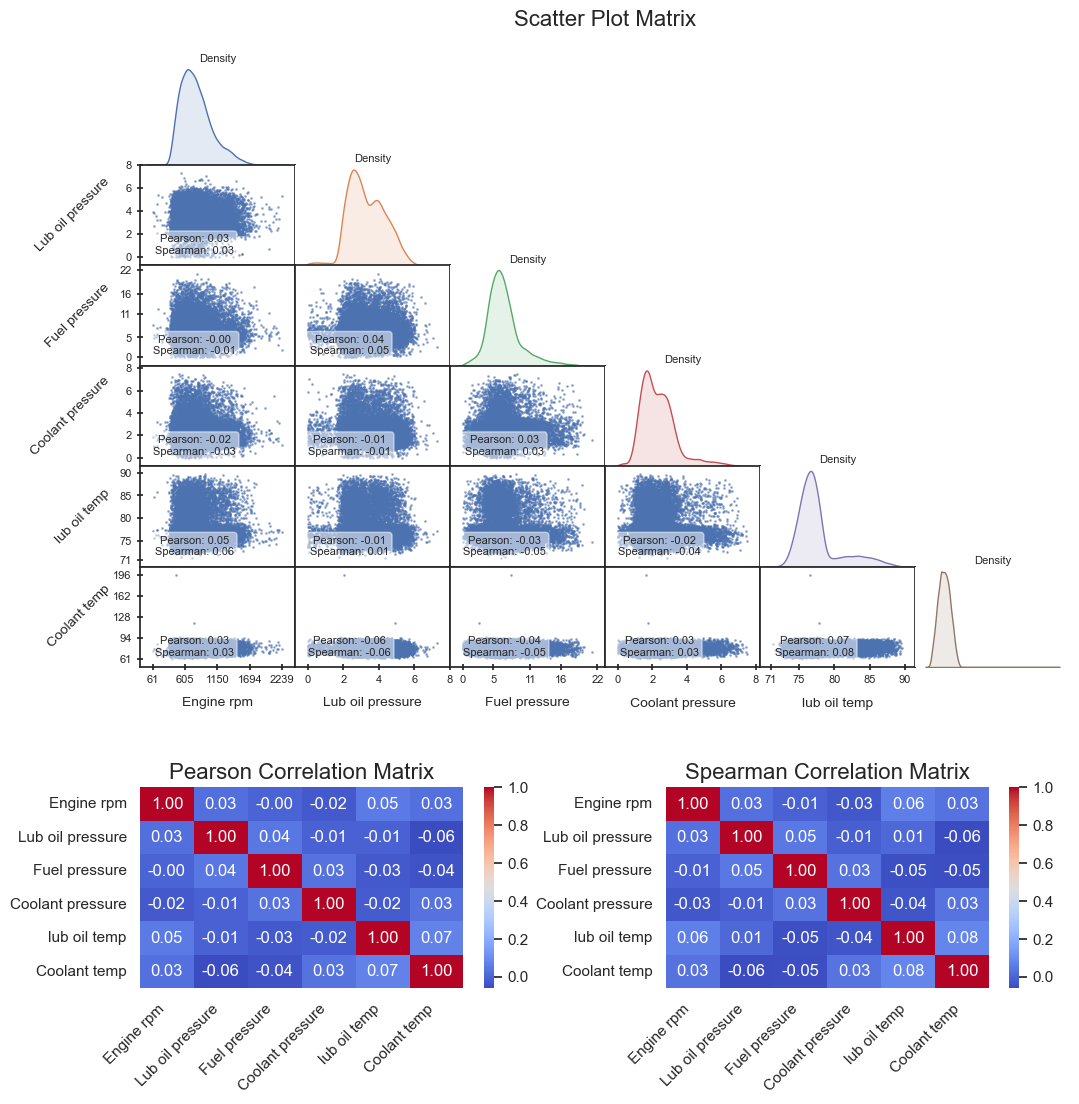

In [ ]:
# @title correlation matrices for numerical variables
# Plotting and Calculating Correlation Coefficients for all Feature Pair Combinations 

def calculate_correlation(x, y, method='pearson'):
    """Calculates the correlation coefficient between two series."""
    if method == 'pearson':
        return x.corr(y, method='pearson')
    elif method == 'spearman':
        return x.corr(y, method='spearman')
    else:
        raise ValueError("Invalid correlation method. Choose 'pearson' or 'spearman'.")

def plot_correlation_matrices(df):
    """
    Plots three figures:
    1. Scatter plot matrix spanning the entire first row 
    2. Pearson correlation matrix in bottom left
    3. Spearman correlation matrix in bottom right

    Args:
        num_df (pd.DataFrame): The input DataFrame containing numerical data.
    """

    # Ensure data is a DataFrame
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input data must be a pandas DataFrame.")

    # Ensure data is numerical
    if not all(pd.api.types.is_numeric_dtype(df[col]) for col in df.columns):
        raise ValueError("All columns in the DataFrame must be numeric.")

    # Create the figure with custom GridSpec
    fig = plt.figure(figsize=(12, 12))
    gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1], 
                    wspace=0.3,    # Width space between columns
                    hspace=0.3)    # Height space between rows)
    
    # Create axes: one spanning the entire first row and two in the second row
    ax_scatter = plt.subplot(gs[0, :])  # First row spanning both columns
    ax_pearson = plt.subplot(gs[1, 0])  # Bottom left
    ax_spearman = plt.subplot(gs[1, 1])  # Bottom right

    # 1. Scatter Plot Matrix (spanning entire first row)
    sns.set(style="ticks")

    num_cols = len(df.columns)
    # Create the subplots for the scatter plot matrix
    scatter_axes = [[None for _ in range(num_cols)] for _ in range(num_cols)]
    for i in range(num_cols):
        for j in range(num_cols):
            if j < i:  # Lower triangle: scatter plots
                scatter_axes[i][j] = ax_scatter.inset_axes([j/num_cols, 1-(i+1)/num_cols, 1/num_cols, 1/num_cols])
                scatter_axes[i][j].scatter(df.iloc[:, j], df.iloc[:, i], s=1, alpha=0.5)

                # Calculate and add correlation coefficients
                x_col = df.columns[j]
                y_col = df.columns[i]
                x = df[x_col]
                y = df[y_col]
                pearson_corr = calculate_correlation(x, y, method='pearson')
                spearman_corr = calculate_correlation(x, y, method='spearman')
                scatter_axes[i][j].annotate(
                    f"Pearson: {pearson_corr:.2f}\nSpearman: {spearman_corr:.2f}",
                    xy=(0.35, 0.2), xycoords='axes fraction',
                    ha='center', va='center', fontsize=8,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
                
                # Set the limits to see the data, add margins
                x_margin = (df.iloc[:,j].max() - df.iloc[:,j].min())*0.1
                y_margin = (df.iloc[:,i].max() - df.iloc[:,i].min())*0.1

                scatter_axes[i][j].set_xlim(df.iloc[:,j].min() - x_margin, df.iloc[:,j].max() + x_margin)
                scatter_axes[i][j].set_ylim(df.iloc[:,i].min() - y_margin, df.iloc[:,i].max() + y_margin)

                # Remove ticks and labels from internal plots
                scatter_axes[i][j].set_xticks([])
                scatter_axes[i][j].set_yticks([])

                # Set ticks only for the leftmost plots (y-axis)
                if j == 0:
                    scatter_axes[i][j].yaxis.set_ticks_position('left')
                    scatter_axes[i][j].tick_params(axis='y', which='major', labelsize=8, length=5, direction='inout')
                    # Set y-ticks based on the data range (even integers)
                    y_min = int(np.floor(df.iloc[:,i].min()))
                    y_max = int(np.ceil(df.iloc[:,i].max()))
                    y_ticks = np.linspace(y_min, y_max, 5).astype(int)
                    scatter_axes[i][j].set_yticks(y_ticks)
                    scatter_axes[i][j].set_yticklabels([f"{tick}" for tick in y_ticks])

                # Set ticks only for the bottom plots (x-axis)
                if i == num_cols-1:
                    scatter_axes[i][j].xaxis.set_ticks_position('bottom')
                    scatter_axes[i][j].tick_params(axis='x', which='major', labelsize=8, length=5, direction='inout')
                    # Set x-ticks based on the data range (even integers)
                    x_min = int(np.floor(df.iloc[:,j].min()))
                    x_max = int(np.ceil(df.iloc[:,j].max()))
                    x_ticks = np.linspace(x_min, x_max, 5).astype(int)
                    scatter_axes[i][j].set_xticks(x_ticks)
                    scatter_axes[i][j].set_xticklabels([f"{tick}" for tick in x_ticks])

            elif i == j:  # Diagonal: density plots
                scatter_axes[i][j] = ax_scatter.inset_axes([j/num_cols, 1-(i+1)/num_cols, 1/num_cols, 1/num_cols])
                sns.kdeplot(df.iloc[:,i], ax=scatter_axes[i][j], color='C'+str(i), legend=False, fill=True, alpha=0.15)
                
                # Set the limits to see the data, add margins
                x_margin = (df.iloc[:,i].max() - df.iloc[:,i].min())*0.1
                scatter_axes[i][j].set_xlim(df.iloc[:,i].min() - x_margin, df.iloc[:,i].max() + x_margin)
                
                # Add density label at the top
                scatter_axes[i][j].set_title("Density", fontsize=8, pad=2)

                # Explicitly disable y-axis ticks and labels for density plots
                scatter_axes[i][j].set_yticks([])  # Remove y-ticks
                scatter_axes[i][j].set_ylabel("")  # Remove y-axis label

                # Explicitly disable x-axis ticks and labels for all density plots
                scatter_axes[i][j].set_xticks([])  # Remove x-ticks
                scatter_axes[i][j].set_xlabel("")  # Remove x-axis label

                # Remove the border (spines) of the density plots
                for spine in scatter_axes[i][j].spines.values():
                    spine.set_visible(False)
                    
            else:
                pass

    # Adjust position of labels and font size
    label_offset_x = -0.03
    label_offset_y = -0.05

    # Add shared x-axis labels at the bottom (only for scatter plots)
    for j, label in enumerate(df.columns):
        if j < num_cols - 1:  # Skip the last column (density plot)
            ax_scatter.text(
                (j + 0.5) / num_cols, label_offset_y, label,
                ha='center', va='top', transform=ax_scatter.transAxes,
                rotation=0, fontsize=10)

    # Add shared y-axis labels at the left (only for scatter plots)
    for i, label in enumerate(df.columns):
        if i > 0:  # Skip the first row (density plot)
            ax_scatter.text(
                label_offset_x, (num_cols - i - 0.5) / num_cols, label,
                ha='right', va='center', transform=ax_scatter.transAxes,
                rotation=45, fontsize=10)

    # Disable ticks and labels for the parent axis
    ax_scatter.set_xticks([])
    ax_scatter.set_yticks([])

    # Remove the external border (spines) of the parent axis
    for spine in ax_scatter.spines.values():
        spine.set_visible(False)

    # Set title for the scatter plot matrix with adjusted font size
    ax_scatter.set_title("Scatter Plot Matrix", fontsize=16, y=1.05)

    # 2. Pearson Correlation Matrix (bottom left)
    pearson_corr = df.corr(method="pearson")
    sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax_pearson)
    ax_pearson.set_title("Pearson Correlation Matrix", fontsize=16, y=1.0)
    # Rotate x-axis labels
    ax_pearson.set_xticklabels(ax_pearson.get_xticklabels(), rotation=45, ha='right')
    # Rotate y-axis labels
    ax_pearson.set_yticklabels(ax_pearson.get_yticklabels(), rotation=0, va='center')

    # 3. Spearman Correlation Matrix (bottom right)
    spearman_corr = df.corr(method="spearman")
    sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax_spearman)
    ax_spearman.set_title("Spearman Correlation Matrix", fontsize=16, y=1.0)
    # Rotate x-axis labels
    ax_spearman.set_xticklabels(ax_spearman.get_xticklabels(), rotation=45, ha='right')
    # Rotate y-axis labels
    ax_spearman.set_yticklabels(ax_spearman.get_yticklabels(), rotation=0, va='center')

    # Adjust layout and display
  
    plt.show()

plot_correlation_matrices(df)

**Comments:**
All the correlation coefficients are close to zero, indicating that there is no significant linear correlation between any of the features. Interestingly, the scatter plots of coolant temperature versus the other features show a few data points that significantly deviate from the bulk of the data. These points, which represent extremely high coolant temperatures, do not appear to be associated with any specific pattern in the other features (e.g., engine RPMs, temperature of oil, temperature of fuel, etc). This suggests that the high coolant temperatures may anomalies rather than part of a systematic relationship.

#### Test for Normality

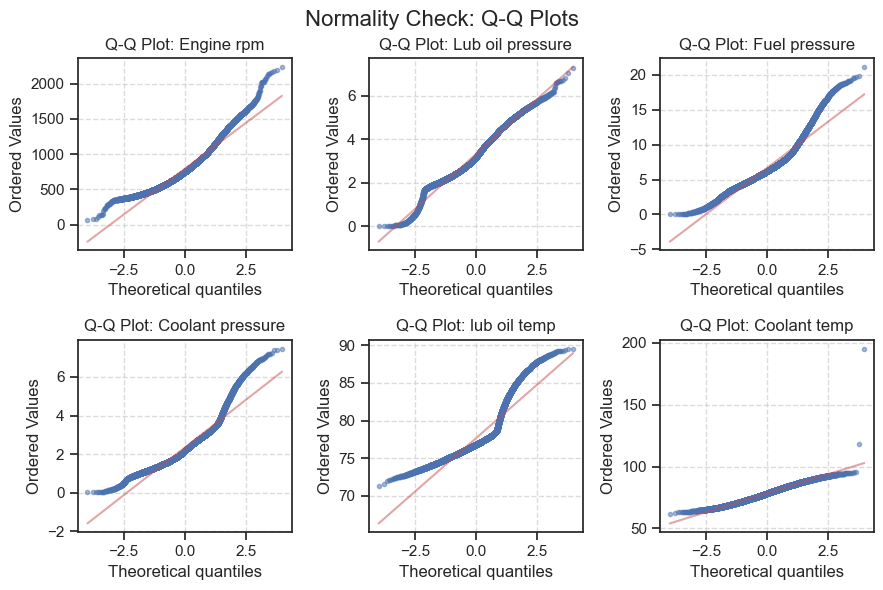

In [ ]:
# @tittle Q-Q plots
# Check for Normality 
# Get features to plot
features = df.columns
# Calculate number of rows and columns needed for subplots
n_features = len(features)
n_cols = 3  # You can adjust this number based on your preference
n_rows = math.ceil(n_features / n_cols)

# Create a figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Empty dictionary to store the results
res = {}

# Create Q-Q plot for each feature
for i, feature in enumerate(features):
    # Create Q-Q plot
    res[feature] = stats.probplot(df[feature], dist="norm", plot=axes[i])
    
    # Set title and adjust appearance
    axes[i].set_title(f'Q-Q Plot: {feature}')
    axes[i].grid(True, linestyle='--', alpha=0.7)
    
    # Adjust size and transparency of data points
    for child in axes[i].get_children():
        if isinstance(child, plt.Line2D):  # Check if the object is a Line2D
            if child.get_marker() != '':  # Check if it's the scatter plot (data points)
                child.set_markersize(3)  # Set size of data points
                child.set_alpha(0.5)  # Set transparency of data points

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

# Add a global title to the figure
plt.suptitle('Normality Check: Q-Q Plots', fontsize=16, y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust to make room for the suptitle
plt.show()

In [ ]:
# @ tittle Normality test
# Due to size of sample > 5000, I used Kolmogorov-Smirnov Test for Normality

# Create empty lists to store results
features_list = []
stat_list = []
p_value_list = []
is_normal_list = []

alpha = 0.05

# Create a dictionary to store results
for feature in df.columns:
    # Standardize the data
    data = (df[feature] - df[feature].mean()) / df[feature].std()
    
    # Compare to standard normal distribution
    stat, p_value = kstest(data, 'norm')
    print(f"Kolmogorov-Smirnov Test for {feature}: Statistic={stat:.4f}, p-value={p_value:.4f}")
    
    if p_value > 0.05:
        print(f"The data for {feature} appears normally distributed (p-value > 0.05)")
    else:
        print(f"The data for {feature} does not appear normally distributed (p-value <= 0.05)")
    print("-" * 50)
    
    # Store results
    features_list.append(feature)
    stat_list.append(stat)
    p_value_list.append(p_value)
    is_normal_list.append(p_value > alpha)
    
# Create a DataFrame with the results for easier analysis
results_df = pd.DataFrame({
    'Feature': features_list,
    'Statistic': stat_list,
    'p_value': p_value_list,
    'Normal Distribution': is_normal_list
})

# Display the results DataFrame
print("\nSummary of Kolmogorov-Smirnov Test Results:")
display(results_df)

Kolmogorov-Smirnov Test for Engine rpm: Statistic=0.0704, p-value=0.0000
The data for Engine rpm does not appear normally distributed (p-value <= 0.05)
--------------------------------------------------
Kolmogorov-Smirnov Test for Lub oil pressure: Statistic=0.0646, p-value=0.0000
The data for Lub oil pressure does not appear normally distributed (p-value <= 0.05)
--------------------------------------------------
Kolmogorov-Smirnov Test for Fuel pressure: Statistic=0.0987, p-value=0.0000
The data for Fuel pressure does not appear normally distributed (p-value <= 0.05)
--------------------------------------------------
Kolmogorov-Smirnov Test for Coolant pressure: Statistic=0.0687, p-value=0.0000
The data for Coolant pressure does not appear normally distributed (p-value <= 0.05)
--------------------------------------------------
Kolmogorov-Smirnov Test for lub oil temp: Statistic=0.1954, p-value=0.0000
The data for lub oil temp does not appear normally distributed (p-value <= 0.05)
--

,Feature,Statistic,p_value,Normal Distribution
0,Engine rpm,0.070423,1.091977e-84,False
1,Lub oil pressure,0.064582,2.797560e-71,False
2,Fuel pressure,0.098702,4.081111e-166,False
3,Coolant pressure,0.068666,1.562157e-80,False
4,lub oil temp,0.195422,0.000000e+00,False
5,Coolant temp,0.020778,9.306486e-08,False


**Comments:**
None of the features are normally distributed:

- We cannot use the z-score for scaling the data, as it assumes a normal distribution. Instead, we can use StandardScaler, 
  which standardizes the data by removing the mean and scaling to unit variance, even if the data is not normally distributed.

- We can use the Interquartile Range (IQR) method for anomaly detection, as it is robust to non-normal distributions.

#### Calculate IQR

In [ ]:
# Calculating IQR and identify any outliers.
# Calculate the quantiles.
quantile_1 = {}
quantile_3 = {}
iqrs = {}

for column in df.columns:
    quantile_1[column] = df[column].quantile(0.25)
    quantile_3[column] = df[column].quantile(0.75)
    iqrs[column] = quantile_3[column] - quantile_1[column]
    
# Combine Q1, Q3, and IQR into a single dictionary
results_quantiles = {
    'Q1': quantile_1,
    'Q3': quantile_3,
    'IQR': iqrs
}
 
iqrs_df = pd.DataFrame(results_quantiles)
iqrs_df

,Q1,Q3,IQR
Engine rpm,593.000000,934.000000,341.000000
Lub oil pressure,2.518815,4.055272,1.536457
Fuel pressure,4.916886,7.744973,2.828087
Coolant pressure,1.600466,2.848840,1.248374
lub oil temp,75.725990,78.071691,2.345700
Coolant temp,73.895421,82.915411,9.019990


In [ ]:
def flag_outliers(df, iqrs):
    """
    Flags outliers in each column of the DataFrame based on the provided lower and upper limits.
    
    Parameters:
    df (pd.DataFrame): The original DataFrame.
    iqrs: Dataframe containing the IQRs for each column.
    
    Returns:
    pd.DataFrame: A DataFrame with an additional column for each feature flagging the anomalies as 1 and the "normal" values as 0.
    """
    # Calculate the upper and lower limits.
    lower_q = {}
    upper_q = {}
    for column in iqrs_df.index:  # Iterate over the index (column names)
        lower_q[column] = iqrs.loc[column, 'Q1'] - 1.5 * iqrs.loc[column, 'IQR']
        upper_q[column] = iqrs.loc[column, 'Q3'] + 1.5 * iqrs.loc[column, 'IQR']
    
    # Create a copy of the original DataFrame to avoid modifying it directly
    anomalies_df = df.copy()
    
    # Iterate over each column in the DataFrame
    for column in df.columns:
        # Check if the column has lower and upper limits defined
        if column in lower_q and column in upper_q:
            # Create new column for the flagged outliers
            anomaly_column_name = f'{column}_anomaly'
            anomalies_df[anomaly_column_name] = (df[column] < lower_q[column]) | (df[column] > upper_q[column]).astype(int)
    # Convert booleans into ints 0,1.
    for column in anomalies_df:
        if anomalies_df[column].dtype == bool:
            anomalies_df[column] = anomalies_df[column].astype(int)
    
    # Add column with the summatory of all anomalies per row 
    anomaly_columns = [col for col in anomalies_df.columns if col.endswith('_anomaly')]
    anomalies_df['anomaly'] = anomalies_df[anomaly_columns].sum(axis=1)
    return anomalies_df


flagged_df = flag_outliers(df, iqrs_df)
flagged_df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_anomaly,Lub oil pressure_anomaly,Fuel pressure_anomaly,Coolant pressure_anomaly,lub oil temp_anomaly,Coolant temp_anomaly,anomaly
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0,0
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0,1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0,1
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0,0
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0,0


In [ ]:
# Identify Number of observations that are flagged as Anomalies in at least 1, 2, 3 features at the same time

anomaly_at_least_one_feature = (flagged_df['anomaly'] > 0).sum()
anomaly_at_least_two_feature = (flagged_df['anomaly'] > 1).sum()
anomaly_at_least_three_feature = (flagged_df['anomaly'] > 2).sum()

# Identify the number of features that must simultaneously be in outlier condition, in order for a sample to be classified as an outlier, such that the total percentage of samples identified as outliers falls within the 1-5% range.

percentage_features_at_least_one_anomaly = (anomaly_at_least_one_feature * 100 / len(df))
percentage_features_at_least_two_anomaly = (anomaly_at_least_two_feature * 100 / len(df))
percentage_features_at_least_three_anomaly = (anomaly_at_least_three_feature * 100 / len(df))

print(f'Anomalies in at least one feature: {anomaly_at_least_one_feature}, % of total observation: {percentage_features_at_least_one_anomaly:.2f}')
print(f'Anomalies in at least two features: {anomaly_at_least_two_feature}, % of total observation: {percentage_features_at_least_two_anomaly:.2f}')
print(f'Anomalies in at least three features: {anomaly_at_least_three_feature}, % of total observation: {percentage_features_at_least_three_anomaly:.2f}')


Anomalies in at least one feature: 4636, % of total observation: 23.73
Anomalies in at least two features: 422, % of total observation: 2.16
Anomalies in at least three features: 11, % of total observation: 0.06


**Comments:**
- 23.73% of observations were flagged as outliers in at least one feature. This proportion is above the recommended threshold of 1-5% for this assignment, suggesting that the criteria for identifying outliers in individual features may be too lenient or that the data contains a significant number of extreme values.
  
- 0.06% of all observations were flagged as outliers in at least three features simultaneously. This proportion is exceptionally low, indicating that the "at least three features" threshold is overly restrictive for identifying meaningful anomalies in this dataset.
  
- 2.16% of all observations were flagged as outliers in at least two features simultaneously. This falls within the recommended range of 1-5%, indicating that the "at least two features" threshold is a reasonable balance for identifying anomalies in this dataset.

#### Scaled Data fot One-class SVM

In [ ]:
# Scale data for better SVM performance. In this case, the X matrix corresponds to the entire dataset. This will be the data used for one-class SVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled)
X_scaled_df.columns = df.columns
X_scaled_df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,-0.408212,-0.892819,-0.738304,0.495596,-0.440709,-1.376412
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158
2,-0.497896,0.127697,-1.077426,-0.633625,3.358026,0.044690
3,-0.157842,-1.183534,0.168533,-0.671293,0.005852,0.637913
4,-0.430633,0.229492,-0.253226,0.858747,-0.776966,-1.816491


#### One-Class Support Vector Machine (SVM)

In [ ]:
# One-Class SVM model using the full scaled dataset
model_full = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.03)
model_full.fit(X_scaled_df)


OneClassSVM(gamma=0.1, nu=0.03)

In [ ]:
# Predict the class (normal or anomaly) on full dataset.
anomalies_full = model_full.predict(X_scaled_df)
# Create new dataframe for data and anomalies predicted.
df_svm = pd.DataFrame(X_scaled_df, columns=X_scaled_df.columns)
df_svm['anomaly'] = anomalies_full

# Display anomalies.
anom_full = df_svm[df_svm.anomaly == -1]
print(f'Anomalies in data set: {len(anom_full)}')

anomalies_full

Anomalies in data set: 586


array([ 1, -1,  1, ...,  1,  1,  1], shape=(19535,))

#### Visualization of One-Class SVM output

In [ ]:
# Reduce dimensionality to 2 features using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)

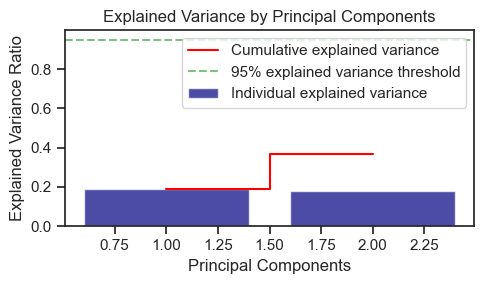

In [ ]:
# If we want additional information about the explained variance
variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

# Create a bar plot of explained variance
plt.figure(figsize=(5, 3))
plt.bar(range(1, len(variance_ratio) + 1), variance_ratio, alpha=0.7, color='navy', 
        label='Individual explained variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', 
         label='Cumulative explained variance', color='red')
plt.axhline(y=0.95, linestyle='--', color='green', alpha=0.5, label='95% explained variance threshold')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

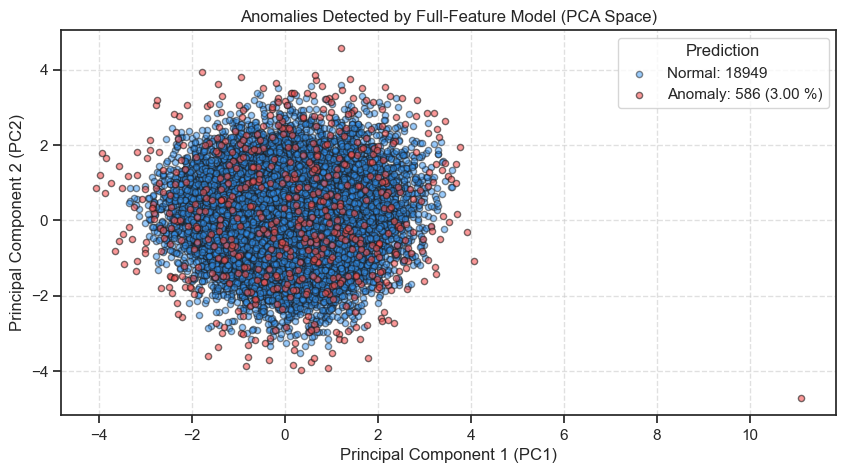

In [ ]:
# Steps to Plot Anomalies from the Full-Feature Model in PCA Space.

def plot_pca_with_full_model_anomalies(anomalies_full, X_pca, title):
    """
    Plots the PCA-reduced data (PC1 and PC2) with anomalies detected by the full-feature model.

    Parameters:
    anomalies_full: The anomaly predictions from the full-feature model (1 for inliers, -1 for anomalies).
    title: The title of the plot.
    X_pca: PCA-reduced data
    """

    # Calculate the counts of normal points and anomalies
    normal_count = np.sum(anomalies_full == 1)
    anomaly_count = np.sum(anomalies_full == -1)

    # Calculate the percentage of anomalies
    percent_anom = (anomaly_count / len(anomalies_full)) * 100

    # Split data into normal and anomaly points
    normal_mask = anomalies_full == 1
    anomaly_mask = anomalies_full == -1

    # Plot setup
    plt.figure(figsize=(10, 5))
    plt.title(title)

    # Plot normal points
    plt.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1], 
                color='#3496f7', marker='o', alpha=0.5, edgecolor='k', 
                label=f'Normal: {normal_count}', s=20)

    # Plot anomaly points
    plt.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1], 
                color='#f75454', marker='o', alpha=0.6, edgecolor='k', s=20, 
                label=f'Anomaly: {anomaly_count} ({percent_anom:.2f} %)')

    # Add the legend
    plt.legend(title='Prediction', loc='upper right')

    # Plot aesthetics
    plt.xlabel('Principal Component 1 (PC1)')
    plt.ylabel('Principal Component 2 (PC2)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Example usage
plot_pca_with_full_model_anomalies(anomalies_full, X_pca, "Anomalies Detected by Full-Feature Model (PCA Space)")

**Comments:**
- One-class SVM prediction on the scaled dataset using all features with gamma=0.1 and nu=0.03 yielded 585 anomalies, representing 3.0% of the total observations. This result falls within the suggested range of 1-5% anomalies for this dataset, based on the instructions for the assignment. For visualization, the dataset was subjected to PCA (Principal Component Analysis) for dimensionality reduction to two components, enabling a 2D plot of the data and the predictions. 

- No clear pattern in terms of the distribution of the anomalies in the PCA space are evident with this approach.
- Important: With only 40% of the cumulative variance explained by the first two principal components, this PCA projection loses a substantial portion of the data’s variability. While useful for visualization, such low variance retention limits its utility for analyses requiring high feature fidelity.

- Jolliffe & Cadima (2016) emphasize context-dependent component selection.
- Scikit-learn (Pedregosa et al., 2011) and Hastie et al. (2009) suggest retaining PCs explaining 70-90% of variance.


#### Visualization of the Anomalies

In [ ]:
# Create new dataframe without the anomaly score column to pass to the PCA model. This dataframe contains scaled features flagged as anomalies by the one-class svm model
 
df_pca_anom = anom_full.drop(columns=['anomaly'])
# Create PCA model with maximum number of components based on number of features
# This model and dataframes can be used to create multiple PCA plots, for all PCs if desired.
pca_anom = PCA(n_components=6)
anom_pca = pca_anom.fit_transform(df_pca_anom)

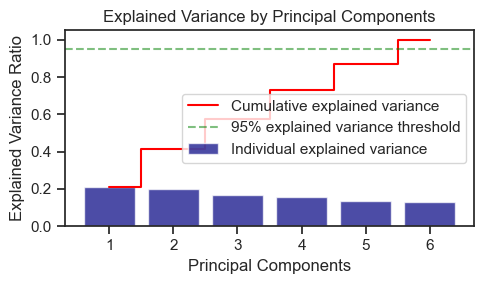

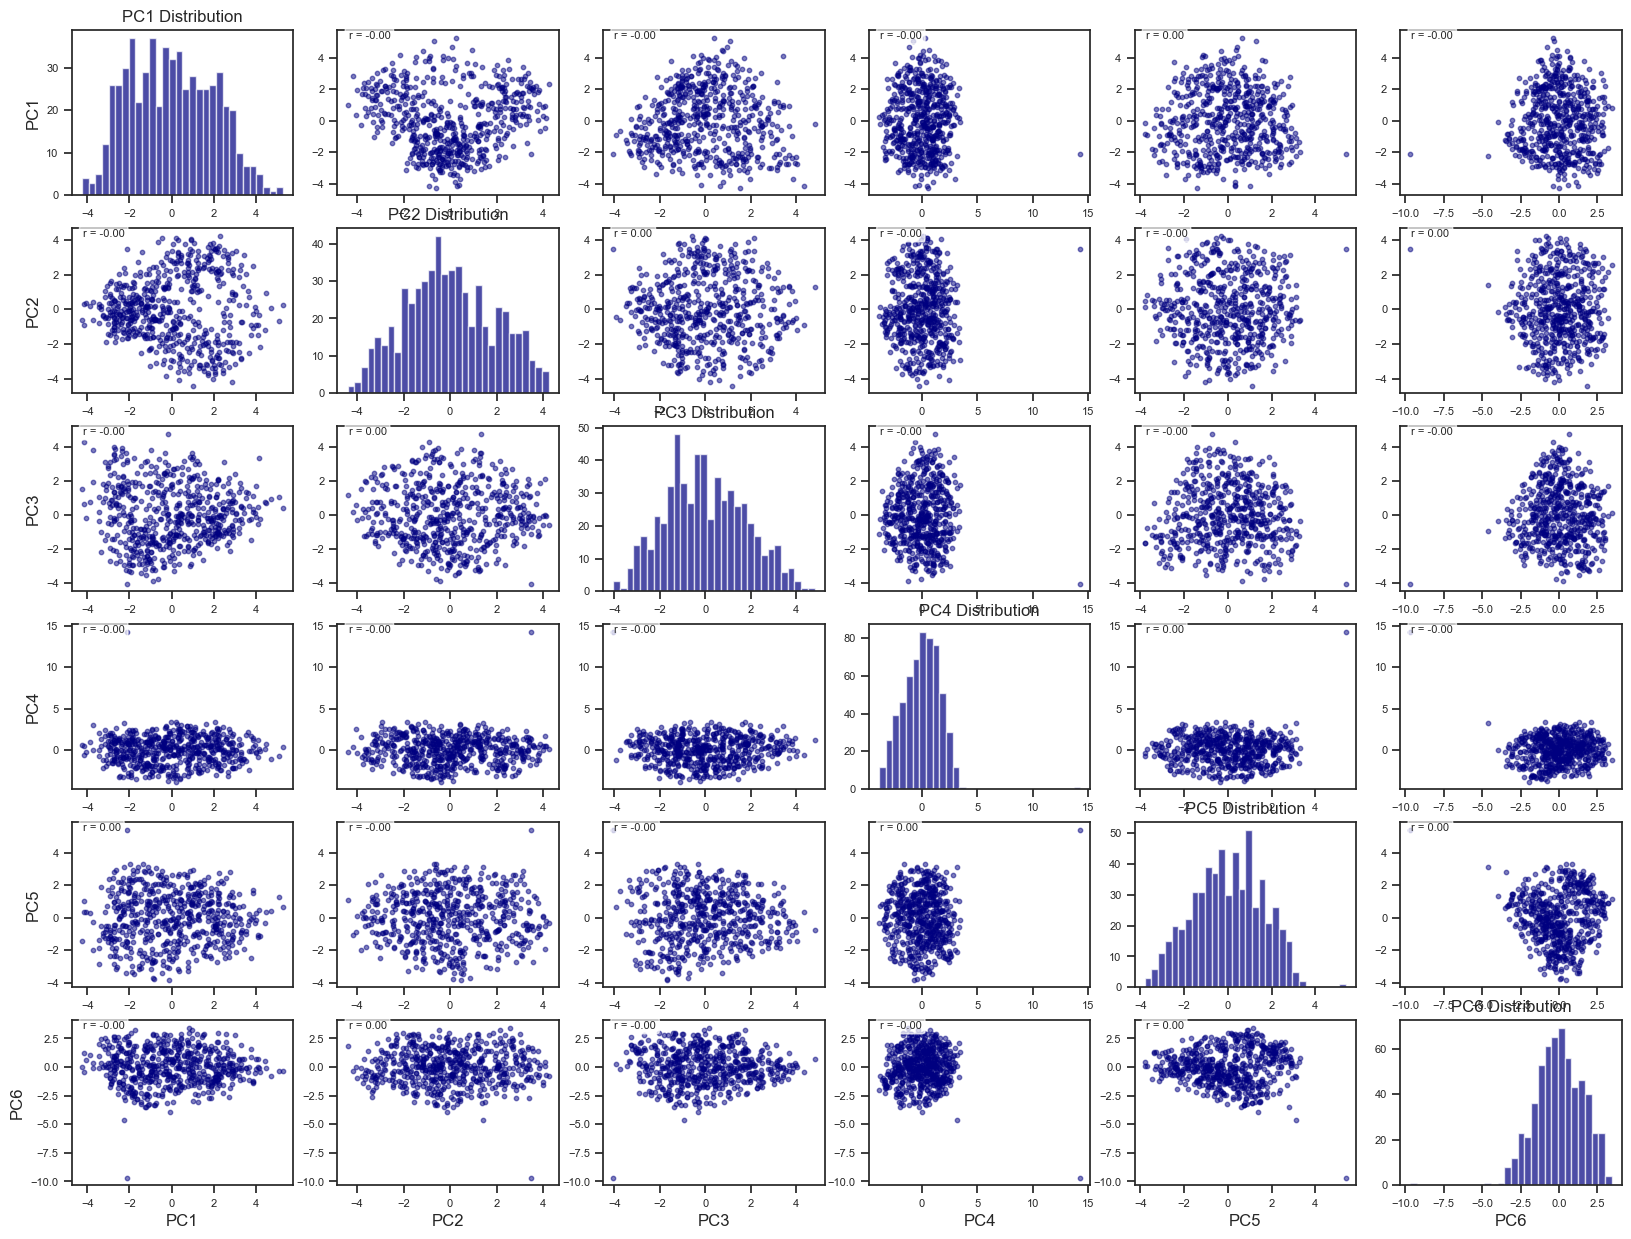

In [ ]:
# @tittle Matrix of PCAs and Explained Variance for all anomalies found in dataset
def plot_pca_matrix(pca_data, figsize=(12, 10)):
    """
    Create a matrix plot of all PCA components against each other.
    
    Parameters:
    -----------
    pca_data : numpy.ndarray
        The PCA transformed data
    figsize : tuple, optional
        Figure size (width, height)
    """
    n_components = pca_data.shape[1]
    
    # Create a figure with a grid of subplots
    fig, axes = plt.subplots(n_components, n_components, figsize=figsize)
    
    # Create a DataFrame for easier plotting
    pca_df = pd.DataFrame(
        data=pca_data,
        columns=[f'PC{i+1}' for i in range(n_components)]
    )
    
    # Plot each component against each other
    for i in range(n_components):
        for j in range(n_components):
            ax = axes[i, j]
            
            if i == j:  # Diagonal: histogram of the component
                ax.hist(pca_df.iloc[:, i], bins=30, color='navy', alpha=0.7)
                ax.set_title(f'PC{i+1} Distribution')
            else:  # Off-diagonal: scatter plot
                ax.scatter(
                    pca_df.iloc[:, j],
                    pca_df.iloc[:, i],
                    alpha=0.5,
                    s=10,
                    color='navy'
                )
                
                # Add correlation coefficient
                corr = np.corrcoef(pca_df.iloc[:, j], pca_df.iloc[:, i])[0, 1]
                ax.annotate(f'r = {corr:.2f}', 
                           xy=(0.05, 0.95), 
                           xycoords='axes fraction',
                           fontsize=8,
                           bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
            
            # Only add labels on the edges
            if i == n_components-1:
                ax.set_xlabel(f'PC{j+1}')
            if j == 0:
                ax.set_ylabel(f'PC{i+1}')
                
            # Remove ticks for cleaner look
            ax.tick_params(axis='both', which='both', labelsize=8)
    


# If you want additional information about the explained variance
variance_ratio = pca_anom.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

# Create a bar plot of explained variance
plt.figure(figsize=(5, 3))
plt.bar(range(1, len(variance_ratio) + 1), variance_ratio, alpha=0.7, color='navy', 
        label='Individual explained variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', 
         label='Cumulative explained variance', color='red')
plt.axhline(y=0.95, linestyle='--', color='green', alpha=0.5, label='95% explained variance threshold')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

plot_pca_matrix(anom_pca, figsize=(20, 15))

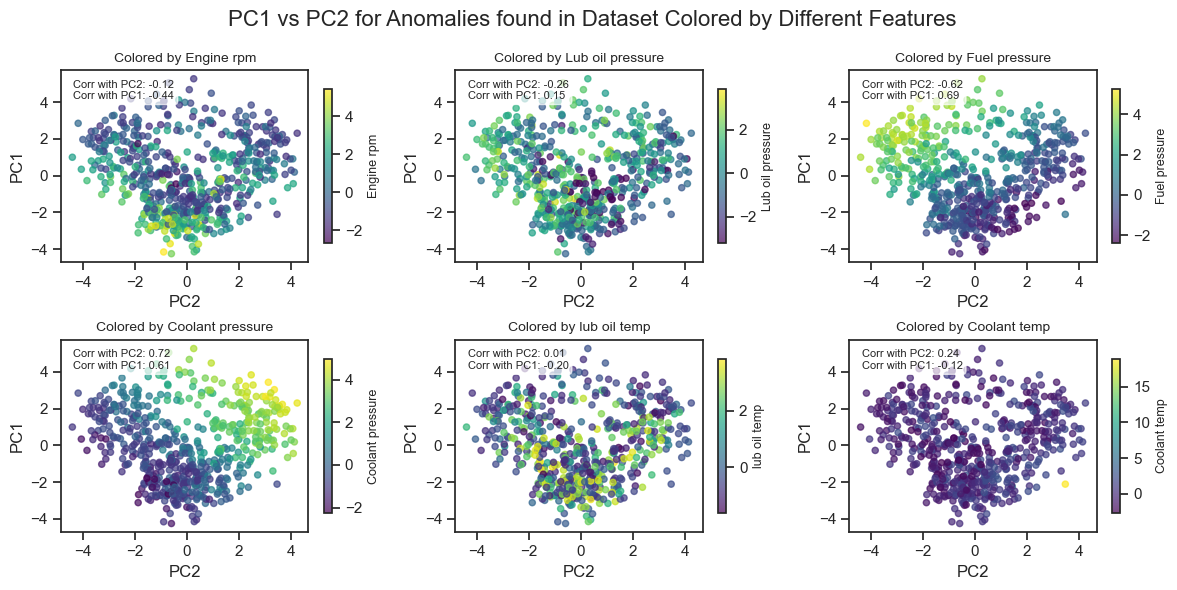

In [ ]:
# @tittle Anomalies found in Dataset Colored by Different Features
# Plotting PC1 vs PC2 and colored the data points based on feature for better visualization

def plot_pca_feature_matrix(pca_data, X_original, pc_pair=(0, 1), max_features=None, figsize=(15, 15)):
    """
    Create a matrix of scatter plots for a specific PC pair, with each plot colored by a different feature.
    
    Parameters:
    -----------
    pca_data : numpy.ndarray
        The PCA transformed data
    X_original : pandas.DataFrame for the anomalies detected
        Original data with features for coloring
    pc_pair : tuple, optional
        Tuple of (i, j) specifying which PC pair to plot (0-indexed)
    max_features : int, optional
        Maximum number of features to plot (will use the first max_features)
    figsize : tuple, optional
        Figure size (width, height)
    
    Returns:
    --------
    matplotlib.figure.Figure
        The figure object containing the matrix of plots
    """
    # Create a DataFrame for the PCA data
    pc_i, pc_j = pc_pair
    pca_df = pd.DataFrame(
        data=pca_data,
        columns=[f'PC{i+1}' for i in range(pca_data.shape[1])]
    )
    
    # Get the feature names
    features = list(X_original.columns)
    
    # Limit the number of features if specified
    if max_features is not None and max_features < len(features):
        features = features[:max_features]
    
    # Calculate grid dimensions
    n_features = len(features)
    n_cols = min(3, n_features)  # Maximum 4 columns
    n_rows = math.ceil(n_features / n_cols)
    
    # Create the figure and axes
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Flatten axes for easier indexing
    if n_features > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    # PC labels for title
    pc_x_label = f'PC{pc_j+1}'
    pc_y_label = f'PC{pc_i+1}'
    
    # Plot each feature
    for idx, feature in enumerate(features):
        if idx < len(axes):
            ax = axes[idx]
            
            # Get feature values for coloring
            if feature in X_original.columns:
                color_values = X_original[feature]
                
                # Create scatter plot colored by the feature
                scatter = ax.scatter(
                    pca_df.iloc[:, pc_j],  # X-axis PC
                    pca_df.iloc[:, pc_i],  # Y-axis PC
                    alpha=0.7,
                    s=20,
                    c=color_values,
                    cmap='viridis'
                )
                
                # Add a colorbar
                cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
                cbar.set_label(feature, fontsize=9)
                
                # Set title and labels
                ax.set_title(f'Colored by {feature}', fontsize=10)
                ax.set_xlabel(pc_x_label)
                ax.set_ylabel(pc_y_label)
                
                # Add correlation between the feature and PCs if numerical
                if np.issubdtype(color_values.dtype, np.number):
                    corr_x = np.corrcoef(color_values, pca_df.iloc[:, pc_j])[0, 1]
                    corr_y = np.corrcoef(color_values, pca_df.iloc[:, pc_i])[0, 1]
                    ax.annotate(f'Corr with {pc_x_label}: {corr_x:.2f}\nCorr with {pc_y_label}: {corr_y:.2f}', 
                               xy=(0.05, 0.95), 
                               xycoords='axes fraction',
                               fontsize=8,
                               verticalalignment='top',
                               bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
    
    # Hide any unused subplots
    for j in range(n_features, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    
    # Add a title to the entire figure
    plt.suptitle(f'{pc_y_label} vs {pc_x_label} for Anomalies found in Dataset Colored by Different Features', fontsize=16)
    


plot_pca_feature_matrix(anom_pca, df_pca_anom, pc_pair=(0, 1), max_features=None, figsize=(12, 6))


**Comments:**
- The code calculates and visualizes the correlation between a numerical feature and two principal components.
- The correlation values help us understand how much the feature contributes to each PC.
- If feature value has a high absolute correlation value with a PC, it means that this feature contributes significantly to that PC.
- This information can help us understand which features are driving the variation captured by the PCs.

Limitations

- Linear Assumption:
    - PCA assumes linear relationships between features. If the data has complex nonlinear relationships, PCA may not capture all the important variance.
- Loss of Interpretability:
    - While PCA helps identify important features, the PCs themselves are linear combinations of the original features and may not be easily interpretable.


#### Isolation Forest

In [ ]:
# Initialize and fit Isolation Forest on scaled dataset (if ranges are too different, as in this case)
iso_forest = IsolationForest(n_estimators=500, contamination=0.03, max_features=3, random_state=42)
# Train model on original scaled data
iso_forest.fit(X_scaled_df)
# Calculate scores for normal and anomaly observations
scores_pred = iso_forest.decision_function(X_scaled_df)
# Predict the anomalies (1 for not anomaly, -1 for anomaly).
y_pred_iso_for = iso_forest.predict(X_scaled_df)


# Make a copy of dataframe to work on
df_iso_for = X_scaled_df.copy()
# Add anomaly column to DataFrame.
df_iso_for['anomaly'] = y_pred_iso_for
# View output.
df_iso_for

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,anomaly
0,-0.408212,-0.892819,-0.738304,0.495596,-0.440709,-1.376412,1
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158,-1
2,-0.497896,0.127697,-1.077426,-0.633625,3.358026,0.044690,1
3,-0.157842,-1.183534,0.168533,-0.671293,0.005852,0.637913,1
4,-0.430633,0.229492,-0.253226,0.858747,-0.776966,-1.816491,1
...,...,...,...,...,...,...,...
19530,-0.411949,0.288774,0.233701,-1.208058,-0.461752,-1.382184,1
19531,-0.789372,-1.038290,-0.511826,-0.833709,-0.243824,1.397013,1
19532,-0.654845,0.006141,-1.038745,3.537070,-0.563698,-1.000134,1
19533,1.389218,-0.559945,-1.069205,0.594695,-0.276059,0.478951,1


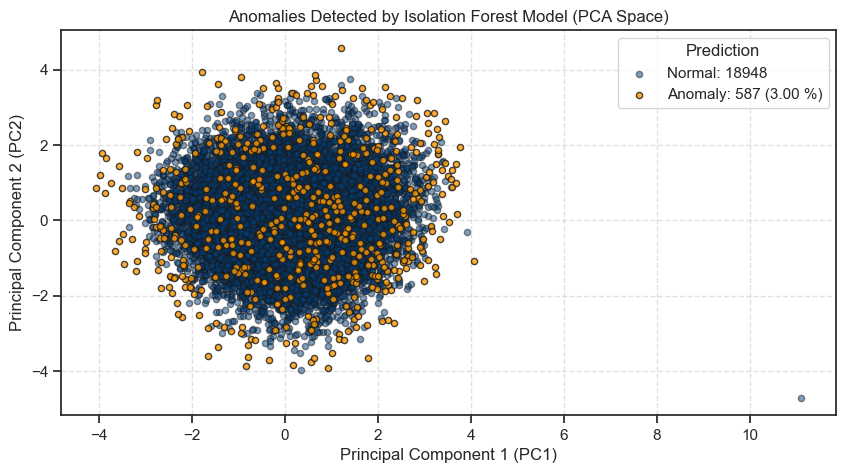

In [ ]:
# Plot Anomalies from the Full-Feature Model in PCA Space.

def plot_pca_with_full_model_anomalies(anomalies_full, X_pca, title):
    """
    Plots the PCA-reduced data (PC1 and PC2) with anomalies detected by the full-feature model.

    Parameters:
    anomalies_full: The anomaly predictions from the full-feature model (1 for inliers, -1 for anomalies).
    title: The title of the plot.
    X_pca: PCA-reduced data
    """

    # Calculate the counts of normal points and anomalies
    normal_count = np.sum(anomalies_full == 1)
    anomaly_count = np.sum(anomalies_full == -1)

    # Calculate the percentage of anomalies
    percent_anom = (anomaly_count / len(anomalies_full)) * 100

    # Split data into normal and anomaly points
    normal_mask = anomalies_full == 1
    anomaly_mask = anomalies_full == -1

    # Plot setup
    plt.figure(figsize=(10, 5))
    plt.title(title)

    # Plot normal points
    plt.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1], 
                color='#004080', marker='o', alpha=0.5, edgecolor='k', 
                label=f'Normal: {normal_count}', s=20)

    # Plot anomaly points
    plt.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1], 
                color='#ff9900', marker='o', alpha=0.8, edgecolor='k', s=20, 
                label=f'Anomaly: {anomaly_count} ({percent_anom:.2f} %)')

    # Add the legend
    plt.legend(title='Prediction', loc='upper right')

    # Plot aesthetics
    plt.xlabel('Principal Component 1 (PC1)')
    plt.ylabel('Principal Component 2 (PC2)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Example usage
plot_pca_with_full_model_anomalies(y_pred_iso_for, X_pca, "Anomalies Detected by Isolation Forest Model (PCA Space)")

In [ ]:
# Check the problematic observation
max_values = df.max()
min_values = df.min()
extreme_df = pd.DataFrame([max_values, min_values], index=['Max', 'Min'])
extreme_df

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
Max,2239.0,7.265566,21.138326,7.478505,89.580796,195.527912
Min,61.0,0.003384,0.003187,0.002483,71.321974,61.673325


In [ ]:
# Check the problematic observation
extreme_case = df[df['Coolant temp'] == df['Coolant temp'].max()]
extreme_case

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
10663,455,2.010802,7.806127,1.619575,76.519385,195.527912


**Comments:**
Isolation Forest (IF) with n_estimators=200 and contamination=0.03 identified 587 anomalies (3.0% of observations), consistent with the recommended 1–5% range for anomaly detection for the assignment. While this meets the assignment criteria, domain-specific thresholds could further optimize results. 

IF vs. OCSVM: Though both methods detected the same number of anomalies, only 64% overlapped. This discrepancy arises from their methodological differences, with IF excelling at detecting local anomalies (isolated points) and OCSVM performing better at targeting global anomalies (dense regions).

Interestingly, the anomalies appear scattered in PCA space (PC1 + PC2 explain ~40% of variance). This is expected because:

Detection methods (IQR, OCSVM, IF) flag anomalies based on feature-wise irregularities (e.g., extreme values) rather than spatial proximity in 2D projections.
Anomalies may be driven by higher PCs (e.g., PC3, PC4) or non-linear patterns, which PCA (a linear method) cannot capture.

Global outliers (outside the main cloud) may indicate data errors (e.g., extreme coolant temperature), however, careful validation should be considered due to potential significance. On the other hand, local outliers (within the cloud) likely reflect anomalies observed in certain feature combinations, but not in others. This heterogeneity in anomaly distributions across features is are common in system failure analysis, since irregularities may occur at different times and affect different elements of the system.


Next steps:
Label anomalies using domain knowledge (e.g., "high-temperature events").
Supplement PCA with feature-specific plots (e.g., parallel coordinates).
Document that scattered patterns reflect real-world diversity, not model flaws.


#### Comparison Three Different Methods

In [ ]:
# Make copy or original flagged dataframe
iqr_2_df = flagged_df.copy()
# Select columns containing '_anomaly' and sum across rows
iqr_2_df['anomaly'] = iqr_2_df.filter(like='_anomaly').sum(axis=1)
# Encode directly in the original column (if you want to replace it)
iqr_2_df['total_anomaly'] = iqr_2_df['anomaly'].apply(lambda x: 1 if x <= 1 else -1)

# Drop unneeded columns
columns_to_drop = iqr_2_df.columns[6:12]  # Columns 6 through 11
iqr_2_df = iqr_2_df.drop(columns=columns_to_drop)

# Replace 'anomaly' values with 'total_anomaly' values
iqr_2_df['anomaly'] = iqr_2_df['total_anomaly']
# Drop the 'total_anomaly' column
iqr_2_df = iqr_2_df.drop(columns=['total_anomaly'])

# Data frame with anomalies from One-Class SVM (Dropped the anomaly column)
svm_anom_df = df_svm.copy()

# Data frame with anomalies from Isolation Forest (Dropped the anomaly column)
iso_for_anom_df = df_iso_for.copy()

print(len(iqr_2_df))
print(len(svm_anom_df))
print(len(iso_for_anom_df))

19535
19535
19535


In [ ]:
encoded_anomalies_iqr_2_df = (iqr_2_df['anomaly'] == -1).sum()
encoded_anomalies_svm_anom_df = (svm_anom_df['anomaly'] == -1).sum()
encoded_anomalies_iso_for_anom_df = (iso_for_anom_df['anomaly'] == -1).sum()
print(encoded_anomalies_iqr_2_df)
print(encoded_anomalies_svm_anom_df)
print(encoded_anomalies_iso_for_anom_df)

422
586
587


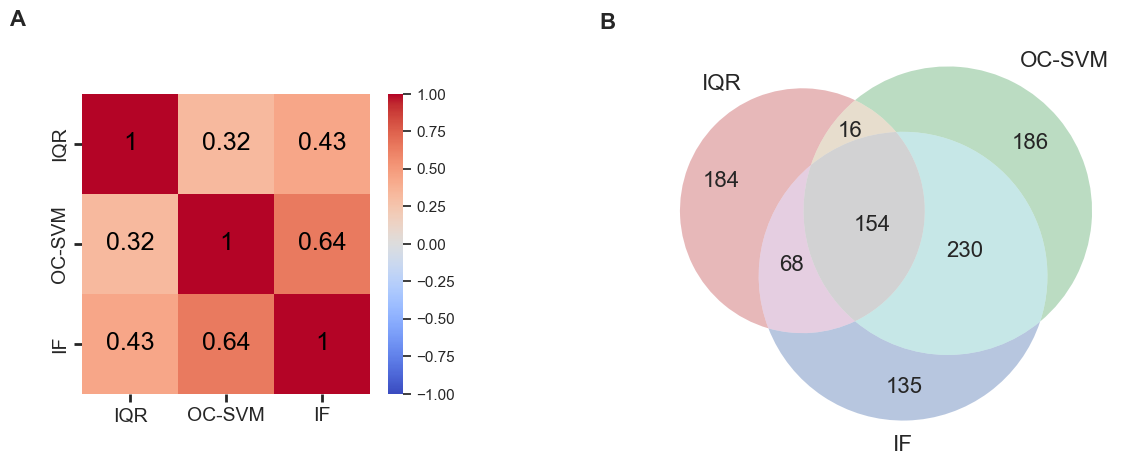

In [ ]:

df1 = iqr_2_df
df2 = svm_anom_df
df3 = iso_for_anom_df

def analyze_anomaly_detection(df1, df2, df3):
    """
    Analyze anomaly detection across multiple methods with improved visualization.
    
    Parameters:
    df1, df2, df3 (pandas.DataFrame): DataFrames with an 'anomaly' column.
    save_path (str): Optional path to save the figure.
    
    Returns:
    dict: Analysis results including common anomalies and statistics.
    """
    # Convert anomaly columns to boolean
    for df in [df1, df2, df3]:
        df['anomaly_bool'] = (df['anomaly'] == -1)

    # Create agreement matrix
    methods_df = pd.DataFrame({
        'IQR': df1['anomaly_bool'],
        'OC-SVM': df2['anomaly_bool'],
        'IF': df3['anomaly_bool']
    })
    agreement_matrix = methods_df.corr()
    
    # Create figure with custom layout
    fig = plt.figure(figsize=(12, 6))
    
    # Create axes with precise positioning
    ax1 = fig.add_axes([0.08, 0.25, 0.3, 0.5])   # Heatmap (left)
    ax2 = fig.add_axes([0.55, 0.15, 0.4, 0.7])    # Venn diagram (right)
    
    # Plot 1: Heatmap
    heatmap = sns.heatmap(agreement_matrix, annot=True, cmap='coolwarm',
                        vmin=-1, vmax=1, center=0, ax=ax1,
                        annot_kws={'size': 14, 'weight': 'normal'})
    
    # Modify heatmap cell labels
    for text in heatmap.texts:
        text.set_fontsize(18)
        text.set_fontweight('normal')
        text.set_color('black')
        text.set_ha('center')
        text.set_va('center')
    
    # Customize heatmap ticks
    ax1.tick_params(axis='both', labelsize=14, width=2, length=6)
    ax1.text(-0.25, 1.28, 'A', transform=ax1.transAxes,
            fontsize=16, fontweight='bold', va='top')
    
    # Plot 2: Venn Diagram
    venn = venn3([
        set(df1[df1['anomaly_bool']].index),
        set(df2[df2['anomaly_bool']].index),
        set(df3[df3['anomaly_bool']].index)
    ], set_labels=('IQR', 'OC-SVM', 'IF'), ax=ax2)
    
    # Adjust Venn diagram labels
    for text in venn.set_labels:
        if text is not None:
            text.set_fontsize(16)
    for text in venn.subset_labels:
        if text is not None:
            text.set_fontsize(16)
    
    ax2.text(-0.1, 1.05, 'B', transform=ax2.transAxes,
            fontsize=16, fontweight='bold', va='top')
    
    # Add figure title
    #fig.suptitle('Comparison of Anomaly Detection Methods', y=0.95, fontsize=14)
    
    # Save figure
    # plt.savefig('comparison_anomalies_three_methods.pdf', 
    #    format='pdf',  # Vector format
    #    bbox_inches='tight',
    #    pad_inches=0.05,
    #    dpi=300)
    
    plt.show()
    
    

analyze_anomaly_detection(df1, df2, df3)

In [ ]:
# Create numpy array with anomalies from IQR method. This is required for the PCA plot.
# Assuming iqr_2_df contains the encoded anomalies for the IQR method for anomalies detected in at least two features
anomalies_iqr = iqr_2_df['anomaly'].astype(int).to_numpy()


In [ ]:
# Modified function to return figures and axis, that output can be used to make grid of plots for different methos
def plot_pca_models(anomalies, pca, title, ax=None):
    """
    Plots PCA-reduced data with anomalies.
    
    Parameters:
    anomalies: Anomaly predictions (1 = normal, -1 = anomaly).
    pca: PCA-transformed data (n_samples, 2).
    title: Plot title.
    ax: Matplotlib axis object (if None, creates a new figure).
    """
    # Calculate counts
    normal_count = np.sum(anomalies == 1)
    anomaly_count = np.sum(anomalies == -1)
    percent_anom = (anomaly_count / len(anomalies)) * 100

    # Split data
    normal_mask = anomalies_full == 1
    anomaly_mask = anomalies_full == -1

    # If no axis provided, create a new figure
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    # Plot normal points
    ax.scatter(
        pca[normal_mask, 0], pca[normal_mask, 1],
        color='#89c3f3', marker='o', alpha=0.5, edgecolor='k',
        label=f'Normal: {normal_count}', s=20
    )

    # Plot anomalies
    ax.scatter(
        pca[anomaly_mask, 0], pca[anomaly_mask, 1],
        color='#ff9900', marker='o', alpha=0.8, edgecolor='k',
        s=20, label=f'Anomaly: {anomaly_count} ({percent_anom:.2f}%)'
    )

    # Add legend and labels
    ax.legend(title='Prediction', loc='upper right')
    ax.set_title(title)
    ax.set_xlabel('Principal Component 1 (PC1)')
    ax.set_ylabel('Principal Component 2 (PC2)')
    ax.grid(True, linestyle='--', alpha=0.6)

    return fig, ax



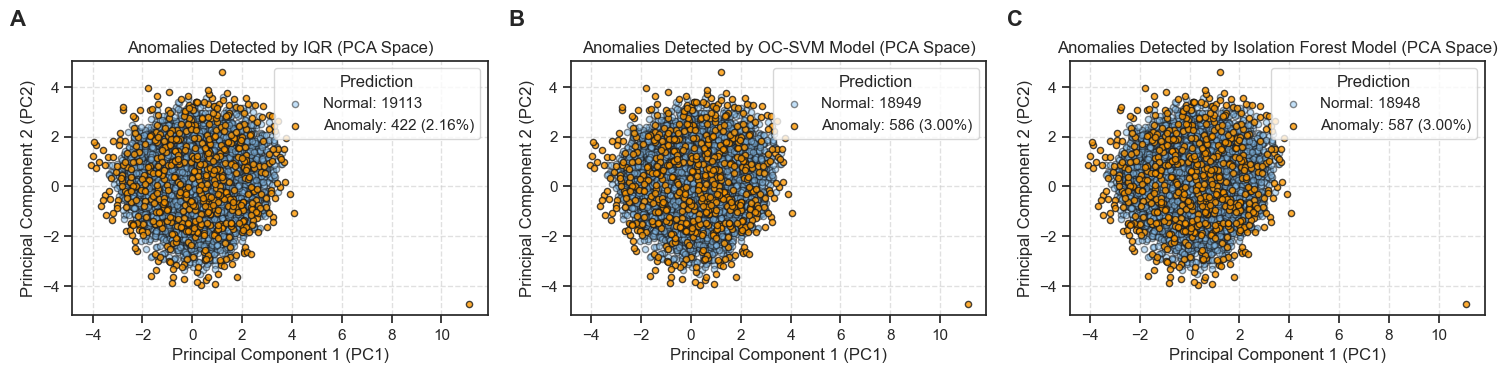

In [ ]:
# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # Wider figure to fit 3 plots

plot_pca_models(anomalies_iqr, X_pca, "Anomalies Detected by IQR (PCA Space)", ax=axes[0])
axes[0].text(-0.15, 1.2, 'A', transform=axes[0].transAxes, fontsize=16,fontweight='bold', va='top')
plot_pca_models(anomalies_full, X_pca, "Anomalies Detected by OC-SVM Model (PCA Space)", ax=axes[1])
axes[1].text(-0.15, 1.2, 'B', transform=axes[1].transAxes, fontsize=16,fontweight='bold', va='top')
plot_pca_models(y_pred_iso_for, X_pca, "Anomalies Detected by Isolation Forest Model (PCA Space)", ax=axes[2])
axes[2].text(-0.15, 1.2, 'C', transform=axes[2].transAxes, fontsize=16,fontweight='bold', va='top')

# Adjust layout to prevent overlap
plt.tight_layout()


plt.subplots_adjust(wspace=0.2)  # Add space between subplots

# plt.savefig('pca_plots_anomalies_three_methods.pdf', 
#            format='pdf',  # Vector format
#            bbox_inches='tight',
#            pad_inches=0.05,
#            dpi=300)

plt.show()

## **Project guidance**
1. Import the required libraries and data set with the provided URL.
2. View the DataFrame and perform EDA, including identifying missing or duplicate values.
3. Generate the descriptive statistics of the data, including:
 - observing the mean for each feature
 - identifying the median
 - idenitfying the range values beyond the 95th percentile for at least two features.
4. Visualise the data to determine the distribution and extreme values.
5. Perform anomaly detection with a statistical method and identify possible anomalies. Specifically:
  - Use the interquartile range (IQR) method to identify outliers for each feature.
  - Create a new column (corresponding to each feature) that will indicate (in binary – 0,1) if the value of that feature is an outlier as per IQR calculations.
  - Use IQR to identify a sample as an outlier only if two or more of the features fall under an outlier category for a particular sample.
  - Record your thoughts and oberservations.
6. Perform anomaly detection with ML models:
  - Perform feature scaling to prepare the data for ML algorithms.
  - Using one-class SVM,
    - identify possible anomalies
    - visualise the output in 2D after performing PCA and ensure the outliers are in a different colour
    - apply different combinations of parameter settings to improve the model's outlier predictions to the expected 1-5%
    - record your insights about the use of this method.
  - Using Isolation Forest,
    - identify possible anomalies
    - visualise the output in 2D after performing PCA and ensure the outliers are in a different colour
    - apply different combinations of parameter settings to improve the model's outlier predictions to the expected 1-5%
    - record your insights about the use of this method.
7. Document your approach and major inferences from the data analysis and describe which method (and parameters) provided the best results and why.
8. When you’ve completed the activity:
  - Download your completed Notebook as an IPYNB (Jupyter Notebook) or PY (Python) file. Save the file as follows: LastName_FirstName_CAM_C101_W5_Mini-project.
  - Prepare a detailed report (between 800-1000 words) that includes:
    - an overview of your approach
    - a description of your analysis
    - an explanation of the insights you identified
    - a summary of which method gave the best results
    - a clear visualisation of your anomaly detection approach
    - an evaluation of the effectiveness of 2D visualisations in highlighting outliers
  - Save the document as a PDF named according to the following convention: LastName_FirstName_CAM_C101_W5_Mini-project.pdf.
  - You can submit your files individually or as a ZIP file. If you upload a ZIP file, use the correct naming convention: LastName_FirstName_CAM_C101_W5_Mini-project.zip.

### Reference:
Devabrat, M., 2022. Predictive Maintenance on Ship's Main Engine using AI. Available at: https://dx.doi.org/10.21227/g3za-v415. [Accessed 5 March 2024]